Epoch: 392  |  Loss: 0.290676  |  c: 0.003395  |  LR: 5.00e-03
Epoch: 393  |  Loss: 0.290412  |  c: 0.003392  |  LR: 5.00e-03
Epoch: 394  |  Loss: 0.306130  |  c: 0.003591  |  LR: 5.00e-03
Epoch: 395  |  Loss: 0.290666  |  c: 0.003395  |  LR: 5.00e-03
Epoch: 396  |  Loss: 0.290283  |  c: 0.003390  |  LR: 5.00e-03
Epoch: 397  |  Loss: 0.290190  |  c: 0.003389  |  LR: 5.00e-03
Epoch: 398  |  Loss: 0.290015  |  c: 0.003387  |  LR: 5.00e-03
Epoch: 399  |  Loss: 0.306713  |  c: 0.003600  |  LR: 5.00e-03
Epoch: 400  |  Loss: 0.289756  |  c: 0.003385  |  LR: 5.00e-03
Total training time: 121.4s
Compliance: 0.002273
Trainable parameters: 1500


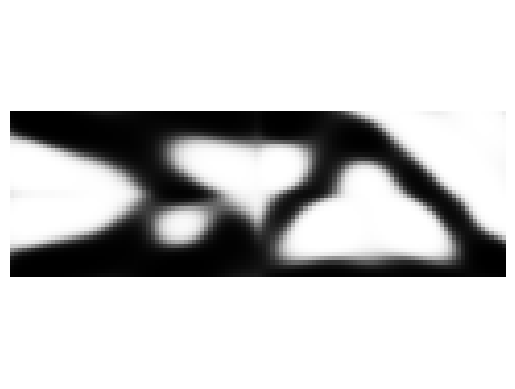

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from IPython import display
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import time

device = 'cuda:2'


# ══════════════════════════════════════════════════════════════════════════════
#  Problem definitions  (unchanged)
# ══════════════════════════════════════════════════════════════════════════════

class Problems():
    def dlX_disp(self):
        domain_xcoord = np.random.uniform(
            -self.nelx / (2 * self.nelm),
             self.nelx / (2 * self.nelm),
            (self.batch_size - self.dlX_fixed.shape[0] - self.dlX_force.shape[0], 1)
        )
        domain_ycoord = np.random.uniform(
            -self.nely / (2 * self.nelm),
             self.nely / (2 * self.nelm),
            (self.batch_size - self.dlX_fixed.shape[0] - self.dlX_force.shape[0], 1)
        )
        domain_coord = np.concatenate((domain_ycoord, domain_xcoord), axis=1)
        coord = np.concatenate(
            (self.dlX_fixed.cpu().detach().numpy(),
             self.dlX_force.cpu().detach().numpy()),
            axis=0
        )
        coord = np.concatenate((coord, domain_coord), axis=0)
        coord = torch.tensor(coord, dtype=torch.float32, requires_grad=True).to(device)
        return coord


class Cantilever_Beam_2D(Problems):
    def __init__(self, nelx, nely, xid, yid, vf):

        # Initialize geometry parameters
        self.xid  = xid
        self.yid  = yid
        self.nelx = nelx
        self.nely = nely

        self.nele     = self.nelx * self.nely
        self.nelm     = max(self.nelx, self.nely)
        self.volfrac  = vf
        self.E0       = 1
        self.nu       = 0.3

        self.batch_size   = 25000
        self.alpha_init   = 1
        self.alpha_max    = 100
        self.alpha_delta  = 0.5
        self.penal        = 3.0

        c_y, c_x = np.meshgrid(
            np.linspace(-(self.nely) / (2 * self.nelm),  (self.nely) / (2 * self.nelm),  self.nely),
            np.linspace(-(self.nelx) / (2 * self.nelm),  (self.nelx) / (2 * self.nelm),  self.nelx),
            indexing='ij'
        )
        self.dlX = np.stack((c_y.reshape([-1]), c_x.reshape([-1])), axis=1).reshape([-1, 2])

        c_y, c_x = np.meshgrid(
            np.linspace(-(self.nely) / (2 * self.nelm),  (self.nely) / (2 * self.nelm),  2 * self.nely),
            np.linspace(-(self.nelx) / (2 * self.nelm),  (self.nelx) / (2 * self.nelm),  2 * self.nelx),
            indexing='ij'
        )
        self.dlXSS = np.stack((c_y.reshape([-1]), c_x.reshape([-1])), axis=1).reshape([-1, 2])
        self.V = (
            (np.max(self.dlX[:, 0]) - np.min(self.dlX[:, 0])) *
            (np.max(self.dlX[:, 1]) - np.min(self.dlX[:, 1]))
        )

        # Boundary conditions
        fixed_voxel         = np.zeros((self.nely, self.nelx))
        fixed_voxel[:, 0]   = 1.0
        fixed_voxel         = fixed_voxel.reshape([self.nele, 1])
        dlX_fixed           = self.dlX[np.where(fixed_voxel == 1.0)[0], :]

        F = 0.1
        self.F_vector   = torch.tensor([[F], [0.0]], dtype=torch.float32).to(device)
        self.force_voxel           = np.zeros((self.nely, self.nelx))
        self.force_voxel[yid, xid] = 1
        force_voxel = self.force_voxel.reshape([self.nele, 1])
        dlX_force   = self.dlX[np.where(force_voxel == 1)[0], :]

        self.dlX      = torch.tensor(self.dlX,      dtype=torch.float32, requires_grad=True).to(device)
        self.dlXSS    = torch.tensor(self.dlXSS,    dtype=torch.float32, requires_grad=True).to(device)
        self.dlX_fixed = torch.tensor(dlX_fixed,    dtype=torch.float32, requires_grad=True).to(device)
        self.dlX_force = torch.tensor(dlX_force,    dtype=torch.float32, requires_grad=True).to(device)

    def analytical_fixed_BC(self, u, coord):
        u = u * 2 * (1 / (1 + torch.exp(-20 * (coord[:, 1:2] + 0.5))) - 0.5)
        return u


# ══════════════════════════════════════════════════════════════════════════════
#  Spectral network backbone  (shared by TO_Net and Disp_Net)
# ══════════════════════════════════════════════════════════════════════════════

_BAND_LOW,  _BAND_HIGH = 0.0, 35.0


def _build_spectral_kernel(n_y: int = 10, n_x: int = 10) -> torch.Tensor:
    c_y, c_x = np.meshgrid(
        np.linspace([-_BAND_HIGH, _BAND_LOW], [-_BAND_LOW, _BAND_HIGH], n_y).ravel(),
        np.linspace([-_BAND_HIGH, _BAND_LOW], [-_BAND_LOW, _BAND_HIGH], n_x).ravel(),
        indexing='ij',
    )
    return torch.tensor(
        np.stack((c_y.ravel(), c_x.ravel()), axis=0),
        dtype=torch.float32,
    )


class _SpectralBase(nn.Module):
    def __init__(self, trainable_kernel: bool, n_y: int = 10, n_x: int = 10):
        super().__init__()
        K = _build_spectral_kernel(n_y, n_x).to(device)
        if trainable_kernel:
            self.kernel1 = nn.Parameter(K)
        else:
            self.register_buffer('kernel1', K)
        self.register_buffer('_bias', torch.ones(1, K.shape[1], dtype=torch.float32))

    def _features(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(x @ self.kernel1 + self._bias)


class TO_Net(_SpectralBase):
    """n_y=n_x=10 → M=400, 可训练参数=1200"""
    def __init__(self, n_y: int = 5, n_x: int = 5):
        super().__init__(trainable_kernel=True, n_y=n_y, n_x=n_x)
        M = self.kernel1.shape[1]
        self.weights1 = nn.Parameter(
            torch.zeros(M, 1, dtype=torch.float32, device=device)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self._features(x) @ self.weights1)


class Disp_Net(_SpectralBase):
    """n_y=10, n_x=15 → M=600 个基函数"""
    def __init__(self, n_y: int = 15, n_x: int = 10):
        super().__init__(trainable_kernel=False, n_y=n_y, n_x=n_x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self._features(x)


# ══════════════════════════════════════════════════════════════════════════════
#  Analytical basis-matrix computation  (replaces M serial autograd calls)
# ══════════════════════════════════════════════════════════════════════════════

def cal_matrix(model: Disp_Net, points: torch.Tensor,
               dlx_force: torch.Tensor, M: int):
    """
    Compute the RFM basis matrix and its spatial gradients analytically.

    For Disp_Net: u[n,m] = sin(z[n,m]) * bc[n]
      where z = points @ K + 1,  bc = 2*(σ(20*(x1+0.5)) − 0.5)

    Gradients (closed-form, no autograd loop over M):
      ∂u/∂y  = cos(z) * K[0] * bc
      ∂u/∂x  = cos(z) * K[1] * bc  +  sin(z) * d(bc)/d(x1)
      d(bc)/d(x1) = 40 * σ * (1 − σ)

    Returns (u1, u_x, u_y, v_force) as float32 numpy arrays.
    """
    K = model.kernel1  # [2, M]

    with torch.no_grad():
        z     = points @ K + model._bias   # [N, M]
        sin_z = torch.sin(z)               # [N, M]
        cos_z = torch.cos(z)               # [N, M]

        # Boundary-condition multiplier (depends on x-coord only)
        x1    = points[:, 1:2]                            # [N, 1]
        sigma = torch.sigmoid(20.0 * (x1 + 0.5))
        bc    = 2.0 * (sigma - 0.5)                       # [N, 1]
        d_bc  = 40.0 * sigma * (1.0 - sigma)              # d(bc)/d(x1) [N, 1]

        u1  = sin_z * bc                                  # [N, M]
        u_y = cos_z * K[0:1, :] * bc                     # [N, M]
        u_x = cos_z * K[1:2, :] * bc + sin_z * d_bc      # [N, M]

        v_force = model(dlx_force)                         # [n_force, M]

    return (
        u1.cpu().numpy(),
        u_x.cpu().numpy(),
        u_y.cpu().numpy(),
        v_force.cpu().numpy(),
    )


# ══════════════════════════════════════════════════════════════════════════════
#  PDE / energy loss
# ══════════════════════════════════════════════════════════════════════════════

# Lamé constants — computed once at module load, not inside the loss function
_E_MOD, _NU_MOD = 1000.0, 0.3
_LAME_MU     = _E_MOD / (2.0 * (1.0 + _NU_MOD))
_LAME_LAMBDA = _E_MOD * _NU_MOD / (1.0 - _NU_MOD ** 2)


def pinnloss2(weights1, u_x, u_y, v_force, problem, xPhys_m):
    xPhys_m = xPhys_m.reshape(-1, 1)

    ux = (u_x @ weights1[:, 1]).reshape(-1, 1)
    uy = (u_y @ weights1[:, 1]).reshape(-1, 1)
    vx = (u_x @ weights1[:, 0]).reshape(-1, 1)
    vy = (u_y @ weights1[:, 0]).reshape(-1, 1)

    eps11 = ux
    eps12 = 0.5 * (uy + vx)
    eps22 = vy

    trace_sq = (eps11 + eps22) ** 2
    diag_sq  = eps11 * eps11 + eps22 * eps22
    energy   = (0.5 * _LAME_LAMBDA * trace_sq
                + _LAME_MU * (diag_sq + 2.0 * eps12 * eps12))
    energy   = energy * (xPhys_m ** 3.0)

    energy_ans = problem.V * torch.mean(energy)
    force_l    = torch.mean(0.1 * (v_force @ weights1[:, 0]).reshape(-1, 1))

    loss = energy_ans - force_l
    return loss, energy


# ══════════════════════════════════════════════════════════════════════════════
#  Block topology-optimization network
# ══════════════════════════════════════════════════════════════════════════════

class TO_BlockNet(nn.Module):
    """
    Partition the design domain into n_cols × n_rows sub-blocks,
    each handled by a separate TO_Net.

    coords: [N, 2] in (y, x) convention.
    """

    def __init__(self, n_cols: int = 2, n_rows: int = 2, device: str = 'cuda:2'):
        super().__init__()
        self.n_cols = int(n_cols)
        self.n_rows = int(n_rows)
        self.device = device
        self.block_nets = nn.ModuleList(
            [TO_Net().to(self.device)
             for _ in range(self.n_cols * self.n_rows + 1)]
        )

    def forward(self, coords: torch.Tensor) -> torch.Tensor:
        coords = coords.to(self.device)
        ys = coords[:, 0:1]
        xs = coords[:, 1:2]

        min_y, max_y = ys.min(), ys.max()
        min_x, max_x = xs.min(), xs.max()
        span_x = max_x - min_x
        span_y = max_y - min_y

        col_idx = ((xs - min_x) / span_x * self.n_cols).long().squeeze(1)
        row_idx = ((ys - min_y) / span_y * self.n_rows).long().squeeze(1)
        col_idx = torch.clamp(col_idx, 0, self.n_cols - 1)
        row_idx = torch.clamp(row_idx, 0, self.n_rows - 1)

        out = torch.zeros(coords.shape[0], 1, device=self.device, dtype=torch.float32)
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                mask = (row_idx == r) & (col_idx == c)
                if mask.sum() == 0:
                    continue
                out[mask] = self.block_nets[r * self.n_cols + c](coords[mask])
        return out

    def eval_block(self, idx: int, coords: torch.Tensor) -> torch.Tensor:
        return self.block_nets[idx](coords.to(self.device))

    def num_blocks(self) -> int:
        return self.n_cols * self.n_rows


# ══════════════════════════════════════════════════════════════════════════════
#  Interface continuity loss
# ══════════════════════════════════════════════════════════════════════════════

def continueloss(to_model: TO_BlockNet, problem) -> torch.Tensor:
    n_samples   = 500
    delta       = 0

    min_y = torch.min(problem.dlX[:, 0]).item()
    max_y = torch.max(problem.dlX[:, 0]).item()
    min_x = torch.min(problem.dlX[:, 1]).item()
    max_x = torch.max(problem.dlX[:, 1]).item()

    cont_loss      = torch.tensor(0.0, device=device)
    interface_count = 0

    # Vertical interfaces (column boundaries)
    for k in range(to_model.n_cols - 1):
        iface_x = min_x + (k + 1) * (max_x - min_x) / to_model.n_cols
        ys      = torch.linspace(min_y, max_y, n_samples, device=device).unsqueeze(1)
        l_pts   = torch.cat([ys, torch.full_like(ys, iface_x - delta)], dim=1)
        r_pts   = torch.cat([ys, torch.full_like(ys, iface_x + delta)], dim=1)

        row_for_ys = (((ys - min_y) / (max_y - min_y)) * to_model.n_rows
                      ).long().squeeze(1).clamp(0, to_model.n_rows - 1)

        for r in range(to_model.n_rows):
            mask = (row_for_ys == r)
            if mask.sum() == 0:
                continue
            left_idx  = r * to_model.n_cols + k
            right_idx = r * to_model.n_cols + (k + 1)
            cont_loss += torch.mean(
                (to_model.eval_block(left_idx,  l_pts[mask]) -
                 to_model.eval_block(right_idx, r_pts[mask])) ** 2
            )
            interface_count += 1

    # Horizontal interfaces (row boundaries)
    for k in range(to_model.n_rows - 1):
        iface_y = min_y + (k + 1) * (max_y - min_y) / to_model.n_rows
        xs      = torch.linspace(min_x, max_x, n_samples, device=device).unsqueeze(1)
        b_pts   = torch.cat([torch.full_like(xs, iface_y - delta), xs], dim=1)
        t_pts   = torch.cat([torch.full_like(xs, iface_y + delta), xs], dim=1)

        col_for_xs = (((xs - min_x) / (max_x - min_x)) * to_model.n_cols
                      ).long().squeeze(1).clamp(0, to_model.n_cols - 1)

        for c in range(to_model.n_cols):
            mask = (col_for_xs == c)
            if mask.sum() == 0:
                continue
            bot_idx = k * to_model.n_cols + c
            top_idx = (k + 1) * to_model.n_cols + c
            cont_loss += torch.mean(
                (to_model.eval_block(bot_idx, b_pts[mask]) -
                 to_model.eval_block(top_idx, t_pts[mask])) ** 2
            )
            interface_count += 1

    return cont_loss / max(interface_count, 1)


# ══════════════════════════════════════════════════════════════════════════════
#  Main solver
# ══════════════════════════════════════════════════════════════════════════════

class RFM_TONN():

    def __init__(self, problem, to_model, disp_model):
        self.problem      = problem
        self.disp_model   = disp_model
        self.to_model     = to_model
        self.total_epoch  = 0
        #self.to_optimizer = optim.Adam(self.to_model.parameters(), lr=0.005)
        self.to_optimizer = optim.Adam(self.to_model.parameters(), lr=0.005)
        self.to_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.to_optimizer,
            mode='min',
            factor=0.5,      # LR 缩小倍率
            patience=20,     # 连续 20 个 epoch 无改善则触发
            min_lr=1e-5,     # 学习率下限
            verbose=False,
        )
        self.coord        = problem.dlX_disp()
        self.x0           = np.random.random(M * 3) * 0.01

        _, u_x, u_y, v_force = cal_matrix(self.disp_model, self.coord,
                                           self.problem.dlX_force, M)
        self.u_x     = torch.tensor(u_x,     dtype=torch.float32, device=device)
        self.u_y     = torch.tensor(u_y,     dtype=torch.float32, device=device)
        self.v_force = torch.tensor(v_force, dtype=torch.float32, device=device)
        self.cont_weight      = 50.0   # 初始权重
        self.cont_weight_min  = 1.0    # 下限
        self.cont_weight_max  = 200.0  # 上限
        self.cont_loss_ema    = None   # 连续性损失的指数滑动均值
        self.main_loss_ema    = None   # 主损失的指数滑动均值
        self.ema_alpha        = 0.05   # EMA 平滑系数

    def fit_disp_init(self):
        self.weights1 = nn.Parameter(
            torch.zeros(self.disp_model.kernel1.shape[1], 2,
                        dtype=torch.float32, device=device)
        )
        self.disp_optimizer = optim.Adam([self.weights1], lr=5e-6)

        # Uniform density initialisation
        xPhys_init = torch.full((self.coord.shape[0], 1), 0.5, device=device)
        for _ in range(1000):
            loss, _ = pinnloss2(self.weights1, self.u_x, self.u_y,
                                self.v_force, self.problem, xPhys_init)
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()

        # Reference compliance at uniform density on full grid
        _, u_x, u_y, v_force = cal_matrix(self.disp_model, self.problem.dlX,
                                           self.problem.dlX_force, M)
        u_x     = torch.tensor(u_x,     dtype=torch.float32, device=device)
        u_y     = torch.tensor(u_y,     dtype=torch.float32, device=device)
        v_force = torch.tensor(v_force, dtype=torch.float32, device=device)

        xPhys_ref = torch.full((self.problem.dlX.shape[0], 1), 0.5, device=device)
        _, energy_c = pinnloss2(self.weights1, u_x, u_y, v_force,
                                self.problem, xPhys_ref)
        self.c1  = energy_c
        self.c_0 = torch.mean(energy_c)

    def to_loss(self, coord):
        self.total_epoch += 1
        xPhys_m = self.to_model(coord)
        alpha   = min(self.problem.alpha_init
                      + self.problem.alpha_delta * self.total_epoch,
                      self.problem.alpha_max)

        _, energy_c = pinnloss2(self.weights1, self.u_x, self.u_y,
                                self.v_force, self.problem, xPhys_m)

        class ComputeDeDrho(torch.autograd.Function):
            @staticmethod
            def forward(ctx, xPhys_m, energy_c, coord):
                ctx.save_for_backward(xPhys_m, energy_c, coord)
                return energy_c

            @staticmethod
            def backward(ctx, denergy):
                xPhys_m, energy_c, coord = ctx.saved_tensors
                grad_energy = torch.autograd.grad(
                    outputs=energy_c,
                    inputs=xPhys_m,
                    grad_outputs=denergy,
                    create_graph=True,
                    retain_graph=True,
                )[0]
                return -grad_energy, torch.zeros_like(energy_c), torch.zeros_like(coord)

        c = torch.mean(ComputeDeDrho.apply(xPhys_m, energy_c, coord))

        xPhys_dlX   = self.to_model(self.problem.dlX)
        continueloss1 = continueloss(self.to_model, self.problem)
        vf          = torch.mean(xPhys_dlX)

        # Phase-field regularisation
        epsilon   = 8e-3
        gamma     = 0.1
        grad_phi  = torch.autograd.grad(
            outputs=xPhys_m.sum(),
            inputs=coord,
            create_graph=True,
            retain_graph=True,
        )[0]
        grad_term   = 0.5 * epsilon * torch.mean(torch.sum(grad_phi ** 2, dim=1))
        double_well = (1 / epsilon) * torch.mean(xPhys_m ** 2 * (1 - xPhys_m) ** 2)
        reg_term    = gamma * (grad_term + double_well)

        loss = (alpha * (vf / self.problem.volfrac - 1.0) ** 2
                + c / self.c_0.detach()
                + 0.1 * reg_term + 50*continueloss1) 

        #print(f'Epoch: {self.total_epoch}  |  Loss: {loss.item():.6f}  |  c: {c.item():.6f}')
        cur_lr = self.to_optimizer.param_groups[0]['lr']
        print(f'Epoch: {self.total_epoch}  |  Loss: {loss.item():.6f}  |  c: {c.item():.6f}  |  LR: {cur_lr:.2e}')
        return loss
   
   

    def fit_disp(self, epochs: int = 200):
        for _ in range(epochs):
            xPhys_m = self.to_model(self.coord)
            loss, _ = pinnloss2(self.weights1, self.u_x, self.u_y,
                                self.v_force, self.problem, xPhys_m)
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()

    def fit_to(self, epochs: int = 500):
        self.time_pde     = []
        self.time_density = []

        for epoch in range(epochs):
            t0 = time.time()
            self.fit_disp(50)
            self.time_pde.append(time.time() - t0)

            if epoch % 10 == 1:
                display.clear_output(wait=True)

            t0   = time.time()
            loss = self.to_loss(self.coord)
            self.to_optimizer.zero_grad()
            loss.backward()
            #self.to_optimizer.step()
            self.to_optimizer.step()
            self.to_scheduler.step(loss.item())
            self.time_density.append(time.time() - t0)

            if (epoch + 1) % 100 == 0:
                xPhys_ss = self.to_model(self.problem.dlXSS.to(device))
                tt = xPhys_ss.cpu().detach().numpy().reshape(
                    2 * self.problem.nely, 2 * self.problem.nelx
                )
                fig, ax = plt.subplots()
                ax.imshow(-tt, cmap='gray')
                ax.axis('equal')
                ax.axis('off')
                #fig.savefig(f'./beam2d001{epoch + 1}.pdf', dpi=300)
                plt.close(fig)   # prevent figure accumulation


# ══════════════════════════════════════════════════════════════════════════════
#  Main script
# ══════════════════════════════════════════════════════════════════════════════

nelx = 60
nely = 20
xid  = 59
yid  = 19
vf   = 0.5

problem       = Cantilever_Beam_2D(nelx, nely, xid, yid, vf)
to_model      = TO_BlockNet(2, 2).to(device)
disp_model_h  = Disp_Net().to(device)
M             = disp_model_h.kernel1.shape[1]

opt = RFM_TONN(problem, to_model, disp_model_h)
opt.fit_disp_init()

t_start = time.time()
opt.fit_to(400)
print(f'Total training time: {time.time() - t_start:.1f}s')


# ── Final density field ────────────────────────────────────────────────────────
xPhys_dlX = opt.to_model(opt.problem.dlXSS.to(device))
tt = xPhys_dlX.cpu().detach().numpy().reshape(
    2 * opt.problem.nely, 2 * opt.problem.nelx
)


# ══════════════════════════════════════════════════════════════════════════════
#  FEM compliance verification (fully vectorised assembly)
# ══════════════════════════════════════════════════════════════════════════════

nelx_fem, nely_fem = 120, 40
E_fem, nu_fem      = 1000.0, 0.3
penal_fem          = 3.0


def lk(E: float = 1000.0, nu: float = 0.3) -> np.ndarray:
    """Plane-stress element stiffness matrix."""
    k = np.array([
        0.5 - nu / 6,    1 / 8 + nu / 8,  -0.25 - nu / 12, -1 / 8 + 3 * nu / 8,
       -0.25 + nu / 12, -1 / 8 - nu / 8,   nu / 6,           1 / 8 - 3 * nu / 8,
    ])
    rows = [
        [k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
        [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
        [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
        [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
        [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
        [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
        [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
        [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]],
    ]
    return E / (1 - nu ** 2) * np.array(rows)


KE   = lk(E_fem, nu_fem)
ndof = 2 * (nelx_fem + 1) * (nely_fem + 1)

# ── Vectorised stiffness assembly ─────────────────────────────────────────────
rho_fem = tt.T[:, :]                              # [nelx_fem, nely_fem]

elx_v = np.repeat(np.arange(nelx_fem), nely_fem)    # [nele]
ely_v = np.tile  (np.arange(nely_fem), nelx_fem)    # [nele]
n1_v  = (nely_fem + 1) * elx_v + ely_v              # corner node index

# DOF indices for each element: [nele, 8]
elem_dofs = np.column_stack([
    2 * n1_v,               2 * n1_v + 1,
    2 * (n1_v + nely_fem + 1), 2 * (n1_v + nely_fem + 1) + 1,
    2 * (n1_v + nely_fem + 2), 2 * (n1_v + nely_fem + 2) + 1,
    2 * (n1_v + 1),         2 * (n1_v + 1) + 1,
])  # [nele, 8]

rho_el  = rho_fem[elx_v, ely_v]                         # [nele]
sK_mat  = (rho_el ** penal_fem)[:, None, None] * KE     # [nele, 8, 8]

# Row / column indices via broadcasting (no Python loops)
iK = np.repeat(elem_dofs, 8, axis=1).ravel()            # [nele*64]
jK = np.tile  (elem_dofs, (1, 8)).ravel()               # [nele*64]
sK = sK_mat.ravel()                                     # [nele*64]

K_fem = coo_matrix((sK, (iK, jK)), shape=(ndof, ndof)).tocsc()

# ── Load and boundary conditions ──────────────────────────────────────────────
F_fem       = np.zeros(ndof)
frc_node = nelx_fem * (nely_fem + 1) + nely_fem
F_fem[2 * frc_node + 1] = -0.1

fixeddofs   = np.concatenate([[2 * j, 2 * j + 1] for j in range(nely_fem + 1)])
freedofs    = np.setdiff1d(np.arange(ndof), fixeddofs)

U           = np.zeros(ndof)
U[freedofs] = spsolve(K_fem[freedofs, :][:, freedofs], F_fem[freedofs])

compliance  = float(F_fem @ U)
print(f'Compliance: {compliance:.6f}')

# ── Summary ───────────────────────────────────────────────────────────────────
trainable_params = sum(p.numel() for p in opt.to_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params}')

fig, ax = plt.subplots()
ax.imshow(-tt, cmap='gray')
ax.axis('equal')
ax.axis('off')
plt.show()

二值化后体积分数   : 0.5315
去孤岛后体积分数   : 0.5315
连通域数量         : 1


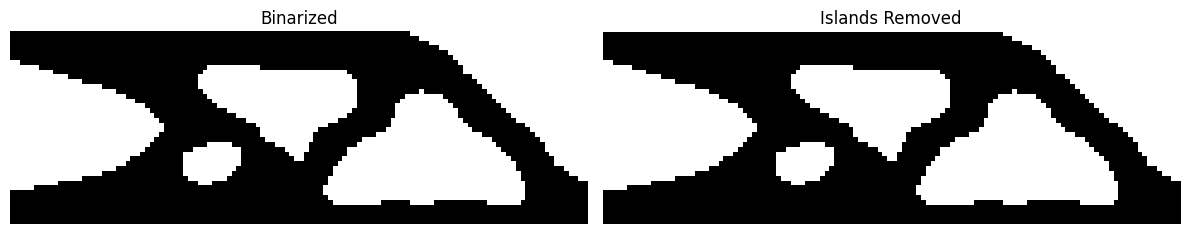

In [2]:
import numpy as np
from scipy.ndimage import label, binary_fill_holes

# ------------------------------------------------------------------ #
#  1. 二值化
# ------------------------------------------------------------------ #
threshold = 0.4
tt_bin = (tt >= threshold).astype(np.uint8)

# ------------------------------------------------------------------ #
#  2. 去除孤岛（保留最大连通域）
# ------------------------------------------------------------------ #
structure = np.ones((3, 3), dtype=int)          # 8-连通
labeled, num_features = label(tt_bin, structure=structure)

if num_features == 0:
    tt_clean = tt_bin.copy()
else:
    # 统计每个连通域的像素数，保留最大的
    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0                      # 背景不参与比较
    largest_label = component_sizes.argmax()
    tt_clean = (labeled == largest_label).astype(np.uint8)

print(f"二值化后体积分数   : {tt_bin.mean():.4f}")
print(f"去孤岛后体积分数   : {tt_clean.mean():.4f}")
print(f"连通域数量         : {num_features}")

# ------------------------------------------------------------------ #
#  3. 可视化对比
# ------------------------------------------------------------------ #
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(1 - tt_bin,  cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Binarized")
axes[0].axis('off')

axes[1].imshow(1 - tt_clean, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Islands Removed")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("tt_clean.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve


def calc_compliance(xPhys, penal=3):
    """
    计算给定密度矩阵的 compliance。

    Parameters
    ----------
    xPhys : np.ndarray, shape (nely, nelx)
        密度矩阵，值域 [0, 1]。
    penal : float
        惩罚指数，默认 3。

    Returns
    -------
    c : float
        结构柔度（compliance）。
    """
    nely, nelx = xPhys.shape

    # ------------------------------------------------------------------ #
    #  MATERIAL PROPERTIES
    # ------------------------------------------------------------------ #
    E0   = 1000.0
    Emin = 1e-9
    nu   = 0.3

    # ------------------------------------------------------------------ #
    #  ELEMENT STIFFNESS MATRIX
    # ------------------------------------------------------------------ #
    A11 = np.array([[ 12,  3, -6, -3],
                    [  3, 12,  3,  0],
                    [ -6,  3, 12, -3],
                    [ -3,  0, -3, 12]])
    A12 = np.array([[ -6, -3,  0,  3],
                    [ -3, -6, -3, -6],
                    [  0, -3, -6,  3],
                    [  3, -6,  3, -6]])
    B11 = np.array([[ -4,  3, -2,  9],
                    [  3, -4, -9,  4],
                    [ -2, -9, -4, -3],
                    [  9,  4, -3, -4]])
    B12 = np.array([[  2, -3,  4, -9],
                    [ -3,  2,  9, -2],
                    [  4,  9,  2,  3],
                    [ -9, -2,  3,  2]])
    KE = (1 / (1 - nu**2) / 24) * (
        np.block([[A11, A12], [A12.T, A11]])
        + nu * np.block([[B11, B12], [B12.T, B11]])
    )

    # ------------------------------------------------------------------ #
    #  DOF MAP
    # ------------------------------------------------------------------ #
    ndof    = 2 * (nelx + 1) * (nely + 1)
    nodenrs = np.arange(1, (1+nelx)*(1+nely)+1).reshape(1+nely, 1+nelx, order='F')
    edofVec = (2 * nodenrs[:nely, :nelx] + 1).reshape(nelx*nely, 1, order='F')
    offsets = np.array([0, 1, 2*nely+2, 2*nely+3, 2*nely, 2*nely+1, -2, -1])
    edofMat = (np.tile(edofVec, (1, 8)) + np.tile(offsets, (nelx*nely, 1)) - 1).astype(int)

    iK = np.tile(edofMat, 8).flatten().astype(int)
    jK = np.repeat(edofMat, 8, axis=1).flatten().astype(int)

    # ------------------------------------------------------------------ #
    #  LOADS AND SUPPORTS
    #  右上角节点施加向下集中力，左边全固定
    # ------------------------------------------------------------------ #
    F = np.zeros(ndof)
    F[2 * (nelx * (nely + 1) + nely) + 1] = -0.1

    fixeddofs = np.arange(0, 2 * (nely + 1))
    freedofs  = np.setdiff1d(np.arange(ndof), fixeddofs)

    # ------------------------------------------------------------------ #
    #  ASSEMBLE & SOLVE
    # ------------------------------------------------------------------ #
    elem_mods = Emin + xPhys.flatten(order='F')**penal * (E0 - Emin)
    sK = (KE.flatten(order='F')[:, None] * elem_mods[None, :]).flatten(order='F')
    K  = sp.csr_matrix((sK, (iK, jK)), shape=(ndof, ndof))
    K  = (K + K.T) / 2

    U = np.zeros(ndof)
    U[freedofs] = spsolve(K[freedofs, :][:, freedofs], F[freedofs])

    # ------------------------------------------------------------------ #
    #  COMPLIANCE
    # ------------------------------------------------------------------ #
    Ue = U[edofMat]
    ce = (Ue @ KE * Ue).sum(axis=1).reshape(nely, nelx, order='F')
    c  = np.sum((Emin + xPhys**penal * (E0 - Emin)) * ce)

    return c

In [4]:
calc_compliance(tt_clean)

0.001797181606173513